# MovieLens — Analysis

Data preprocessing is done in `preprocessing.ipynb`.



In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np    

## Read data

In [3]:
# Load preprocessed data (run preprocessing.ipynb first if needed)
df = pd.read_csv("../data/merged_cleaned.csv")

print(f"Loaded df dataset shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded df dataset shape: (228, 10)
Columns: ['item_id', 'human_#1', 'human_#2', 'human_#3', 'human_#4', 'human_#5', 'human_#6', 'human_#7', 'human_#8', 'GPT-4o-mini']


,item_id,human_#1,human_#2,human_#3,human_#4,human_#5,human_#6,human_#7,human_#8,GPT-4o-mini
0,1,5.0,4.0,NaN,3.0,5.0,NaN,5.0,4.0,5.0
1,4,3.0,NaN,5.0,5.0,3.0,4.0,5.0,3.0,4.0
2,7,4.0,2.0,5.0,2.0,NaN,2.0,5.0,NaN,5.0
3,8,1.0,4.0,5.0,4.0,5.0,NaN,5.0,3.0,4.0
4,9,5.0,4.0,5.0,3.0,5.0,NaN,5.0,4.0,5.0


In [4]:
# Define column names for analysis
HUMAN_COLS = [c for c in df.columns if c.startswith("human_")]
LLM_COLS = ["GPT-4o-mini"]
MIN, MAX = 1, 5

print(f"Human columns: {HUMAN_COLS}")
print(f"LLM columns: {LLM_COLS}")
print(f"Score range: [{MIN}, {MAX}]")

Human columns: ['human_#1', 'human_#2', 'human_#3', 'human_#4', 'human_#5', 'human_#6', 'human_#7', 'human_#8']
LLM columns: ['GPT-4o-mini']
Score range: [1, 5]


## Analysis

In [9]:
# Fix import path - add parent directory to Python path
import sys
import os
sys.path.append(os.path.join(os.getcwd(), '..', '..', '..'))

from core.llm_good_enough import LLMGoodEnough

good_enough = LLMGoodEnough(
    df=df,
    human_cols=HUMAN_COLS,
    llm_cols=LLM_COLS,
    min_score=MIN, max_score=MAX
)

🎲 Random seed: 2210418044
✅ Found 8 valid human annotator columns.
✅ Keeping 228/228 rows with ≥2 human annotators.
✅ Added random judge baseline column: 'RANDOM_as_a_judge'


📊 Computing disagreement distributions...


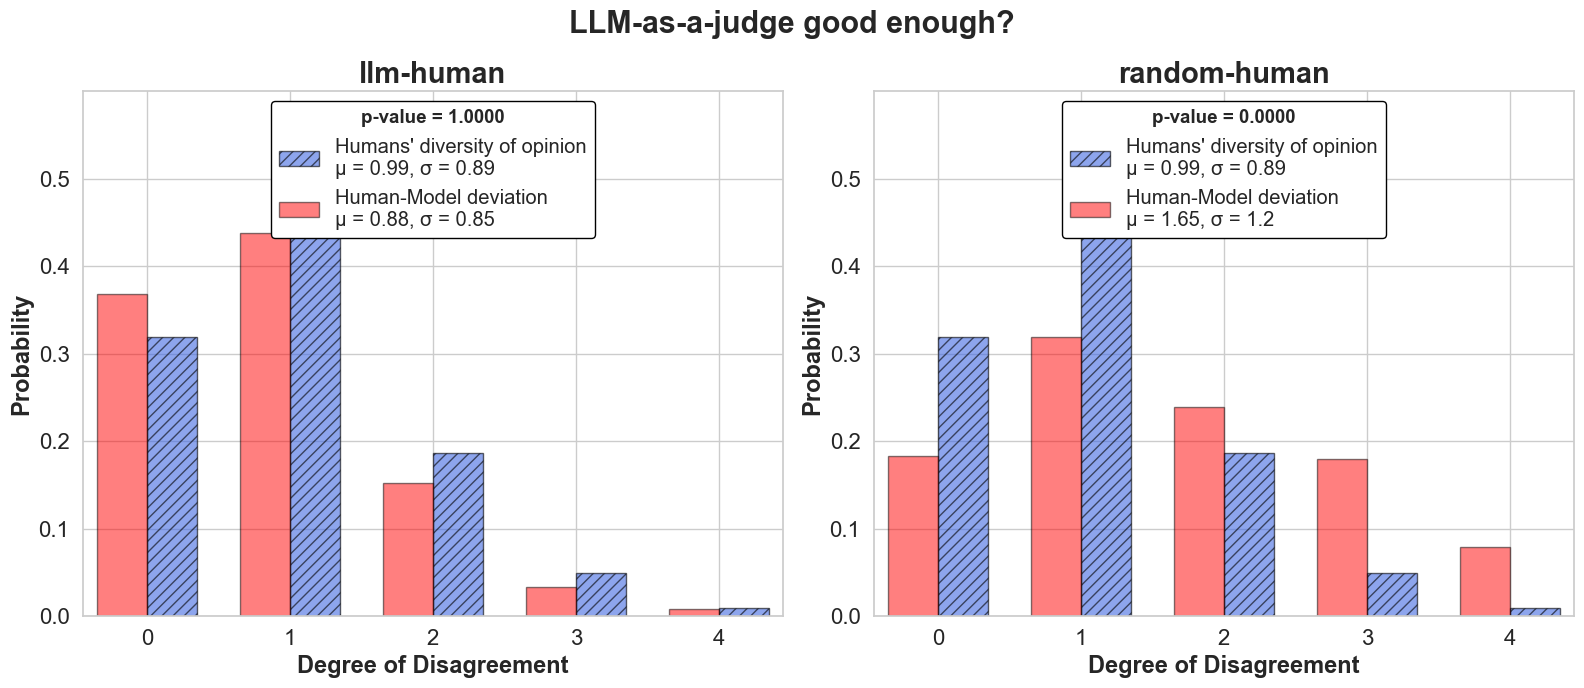

In [10]:
good_enough.visualize_good_enough(llm_col="GPT-4o-mini", y_lim=0.6)

✅ Computed LLM-human disagreements for 1 LLM columns.
✅ Figure saved as SVG → ../figures/svg/movielens_barplot.svg


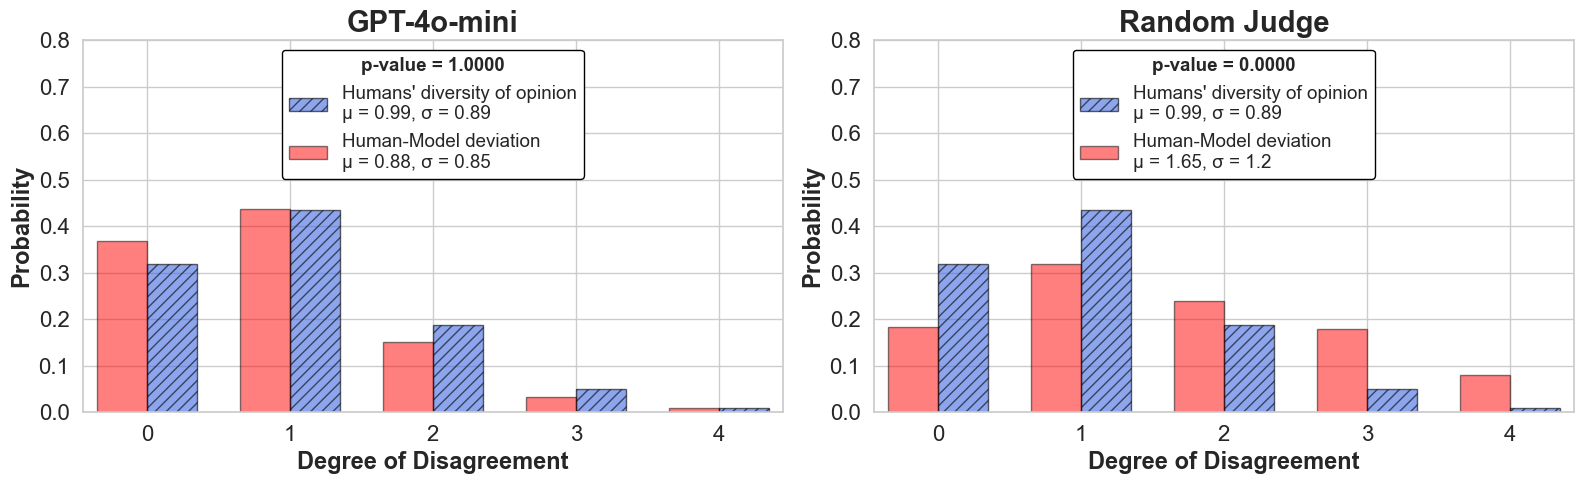

In [13]:
good_enough.plot_judges_grid(
    y_lim=0.8,
    save_path="../figures/svg/movielens_barplot.svg"
)

## Robustness (Monte Carlo)

In [ ]:
good_enough.plot_monte_carlo_robustness(
    llm_col="GPT-4o-mini",
    save_path="../svg/monte_carlo_robustness.svg"
)

## Human stability analysis


In [ ]:
good_enough.plot_human_stability_analysis(
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    parallel=True,
    save_path="../svg/human_stability_analysis.svg"
) 

## LLM stability analysis


✅ Figure saved → ../figures/svg/movielens_llm_stability.svg


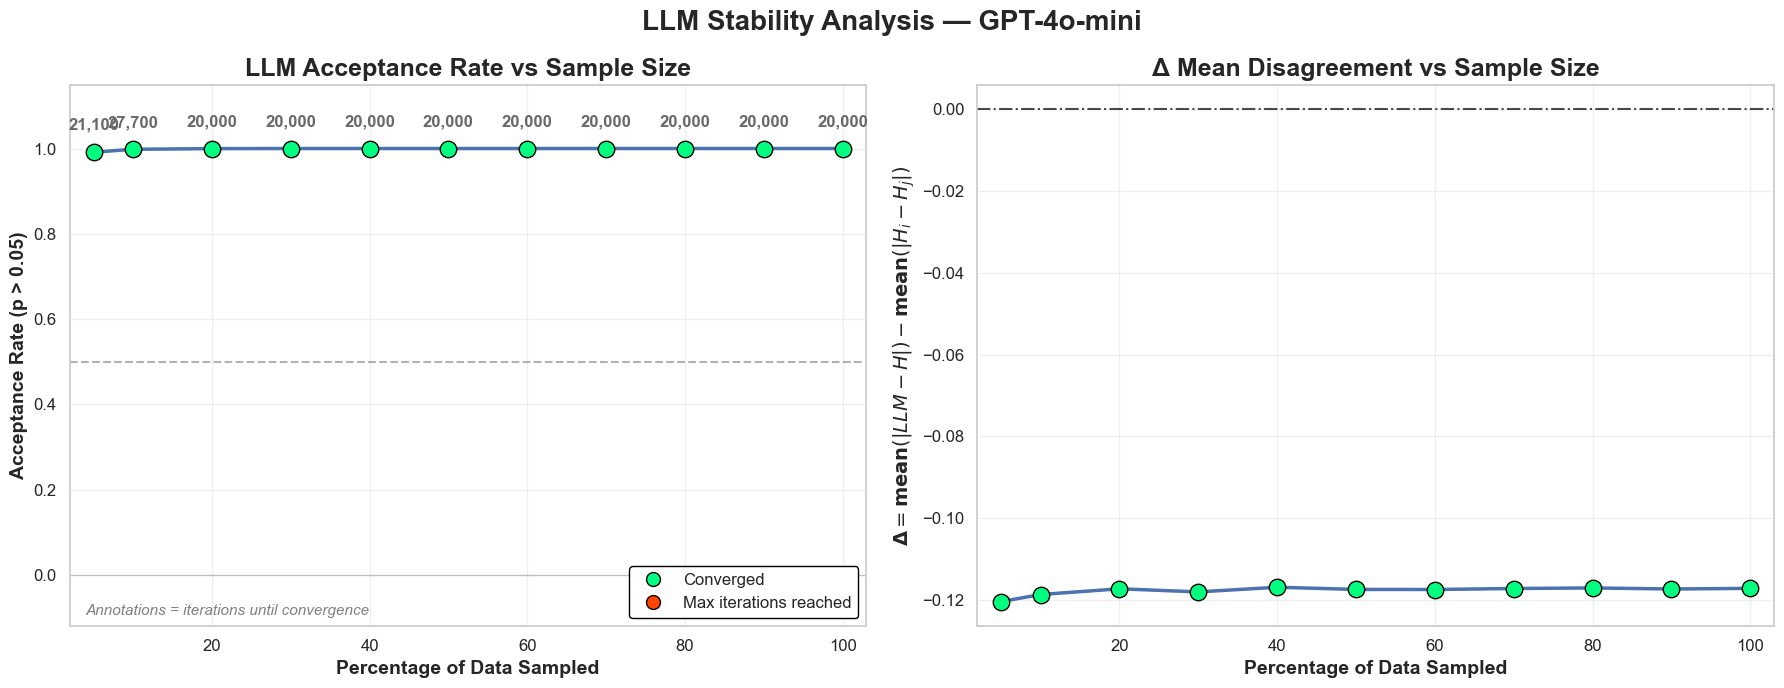

In [14]:
good_enough.plot_llm_stability_analysis(
    llm_col='GPT-4o-mini',
    convergence_threshold=0.000005,
    min_iterations=20_000,
    max_iterations=500_000,
    save_path="../figures/svg/movielens_llm_stability.svg",
    parallel=True,
)